# Aircraft Sensor Data Analysis

Modern aircraft systems rely on multiple sensors to continuously monitor critical components such as engines and power systems.

This project analyzes simulated aircraft sensor data including temperature, vibration, pressure and power consumption.

The objective is to explore the dataset, visualize system behaviour over time and detect potential anomalies that could indicate system faults.

Such analysis techniques are commonly used in predictive maintenance and aerospace system monitoring.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
np.random.seed(42)

n = 500

data = {
    "timestamp": pd.date_range(start="2024-01-01", periods=n, freq="h"),
    "engine_temperature": np.random.normal(75, 5, n),
    "vibration": np.random.normal(3, 0.5, n),
    "pressure": np.random.normal(30, 2, n),
    "power_consumption": np.random.normal(100, 10, n)
}

df = pd.DataFrame(data)

df.head()

,timestamp,engine_temperature,vibration,pressure,power_consumption
0,2024-01-01 00:00:00,77.483571,3.463089,32.798711,107.783611
1,2024-01-01 01:00:00,74.308678,3.954708,31.849267,94.488143
2,2024-01-01 02:00:00,78.238443,2.300716,30.119261,91.818011
3,2024-01-01 03:00:00,82.615149,3.281485,28.706126,99.966255
4,2024-01-01 04:00:00,73.829233,2.674679,31.396447,98.298154


In [4]:
df.describe()

,timestamp,engine_temperature,vibration,pressure,power_consumption
count,500,500.000000,500.000000,500.000000,500.000000
mean,2024-01-11 09:30:00,75.034190,3.015913,30.216969,100.331879
min,2024-01-01 00:00:00,58.793663,1.651557,24.207489,70.596114
25%,2024-01-06 04:45:00,71.498463,2.702354,28.795141,93.880638
50%,2024-01-11 09:30:00,75.063986,3.014266,30.239612,99.910866
75%,2024-01-16 14:15:00,78.183916,3.325621,31.509477,106.997694
max,2024-01-21 19:00:00,94.263657,4.316191,35.203366,131.931076
std,NaN,4.906266,0.488999,2.020493,9.840661


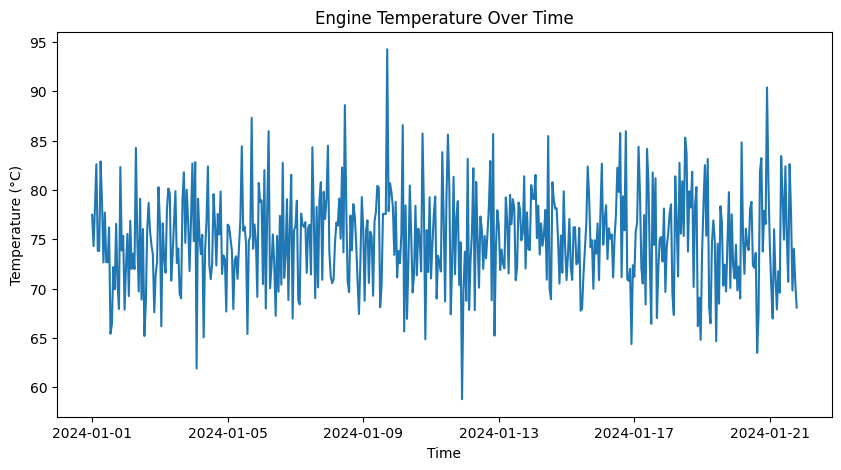

In [5]:
plt.figure(figsize=(10,5))

plt.plot(df["timestamp"], df["engine_temperature"])

plt.title("Engine Temperature Over Time")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")

plt.show()

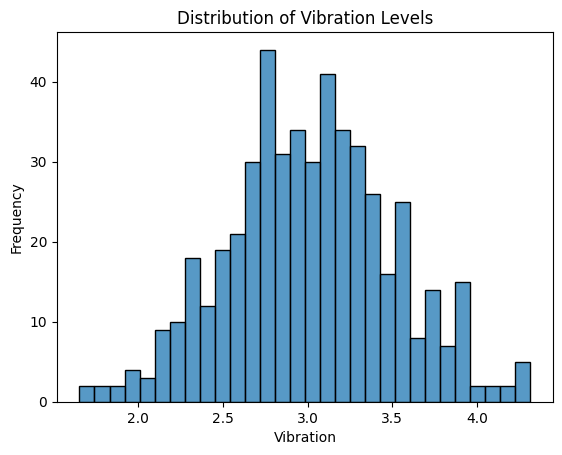

In [6]:
sns.histplot(df["vibration"], bins=30)

plt.title("Distribution of Vibration Levels")

plt.xlabel("Vibration")
plt.ylabel("Frequency")

plt.show()

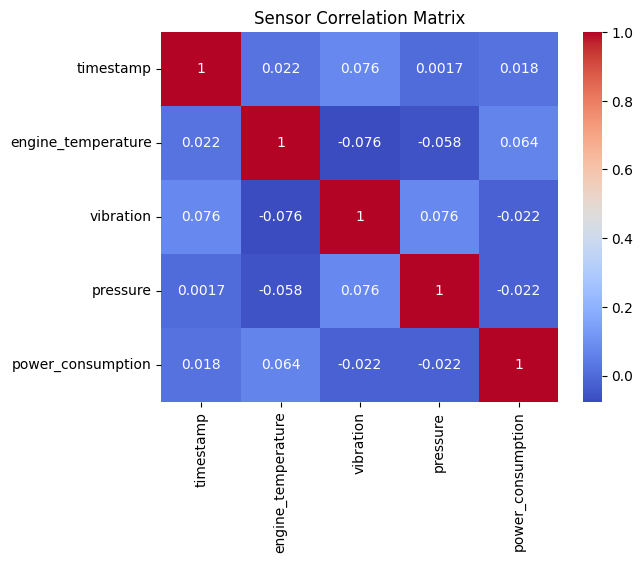

In [7]:
corr = df.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Sensor Correlation Matrix")

plt.show()

In [8]:
threshold = df["engine_temperature"].mean() + 3 * df["engine_temperature"].std()

anomalies = df[df["engine_temperature"] > threshold]

anomalies

,timestamp,engine_temperature,vibration,pressure,power_consumption
209,2024-01-09 17:00:00,94.263657,3.848228,33.499153,90.254707
478,2024-01-20 22:00:00,90.394404,2.208049,28.225016,92.271223


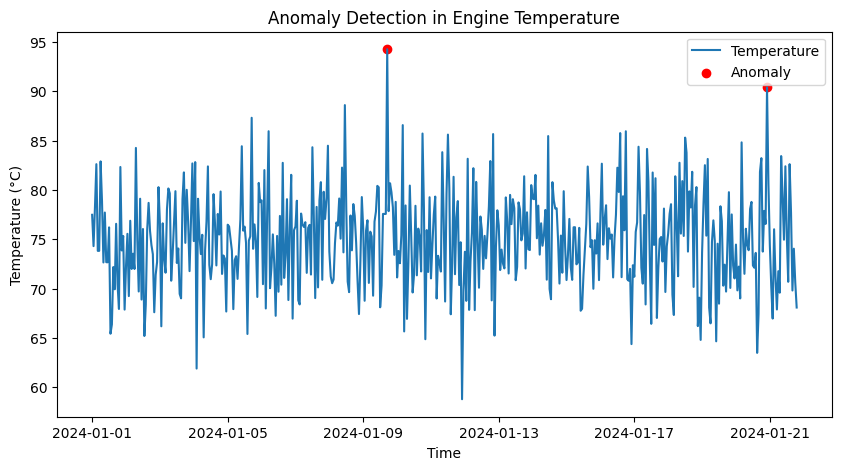

In [9]:
plt.figure(figsize=(10,5))

plt.plot(df["timestamp"], df["engine_temperature"], label="Temperature")

plt.scatter(anomalies["timestamp"], anomalies["engine_temperature"], 
            color="red", label="Anomaly")

plt.legend()

plt.title("Anomaly Detection in Engine Temperature")

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")

plt.show()

# Conclusion

This project demonstrates how sensor data can be analyzed to monitor the behaviour of complex systems such as aircraft engines.

By exploring temperature, vibration, pressure and power consumption data, it is possible to identify patterns and detect abnormal behaviour.

The anomaly detection method used in this project highlights unusual temperature readings that may indicate potential system faults.

Such techniques are commonly applied in predictive maintenance systems used in aerospace and industrial environments.